# 09 · Analysis — one clean frame for every LLM grounding result

The `09_llm_runs/` directory accumulated 30-odd CSVs across three experiment
families, several of them partial reruns. This notebook ingests all of them
into one tidy frame, validates that frame, and derives every number quoted in
Results §3 from it. Nothing downstream should read the raw CSVs directly.

**Three experiment families**

| Family | Queries | Unique diseases | Rows / arm | Used for |
|---|---|---|---|---|
| `main` | 116 | 109 | 696 | Headline comparison |
| `common3` | 76 | 71 | 684 | Coverage-controlled comparison |
| `capacity` | 116 | 109 | 696 each | Llama 1B → 405B series |

`main` and `capacity` share the same 116 queries, so they are directly
comparable. `common3` restricts to pairs present in all three graphs, which is
what isolates evidence quality from evidence availability.

**A note on pairing.** The run files carry no pair identifier and seven
diseases appear twice with different approved drugs, so `disease` alone is not
a key. Queries are emitted in a deterministic, seeded order, so we recover a
`query_idx` from row order within each `(model, kg, seed, shuffle)` group and
assert that it aligns across arms.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

BASE = Path.cwd()
while not (BASE / "config.yaml").exists() and BASE != BASE.parent:
    BASE = BASE.parent
sys.path.insert(0, str(BASE / "src"))

RUNS = BASE / "results" / "tables" / "09_llm_runs"
DERIVED = BASE / "results" / "tables" / "09_derived"
DERIVED.mkdir(parents=True, exist_ok=True)

POOL_SIZE = 8
CHANCE_MRR = float(np.mean([1 / k for k in range(1, POOL_SIZE + 1)]))
CHANCE_HITS1 = 1 / POOL_SIZE
N_BOOT = 10_000
RNG = np.random.default_rng(0)

ARMS = ["none", "primekg", "biokg", "drkg"]
MODEL_CONTRAST_ORDER = ["GPT-4.1-mini", "Gemini-3.1-Flash-Lite",
                        "Llama-3.3-70B"]
KG_LABEL = {"none": "No KG", "primekg": "PrimeKG",
            "biokg": "BioKG", "drkg": "DRKG"}

pd.set_option("display.width", 130)
print(f"repo   {BASE}")
print(f"chance MRR {CHANCE_MRR:.4f}   hits@1 {CHANCE_HITS1:.4f}   pool {POOL_SIZE}")

repo   /sessions/amazing-trusting-pasteur/mnt/biokgsuite
chance MRR 0.3397   hits@1 0.1250   pool 8


## 1 · Manifest

Every file is declared explicitly. A file not listed here is deliberately
excluded, and the reason is recorded in `EXCLUDED`.

In [2]:
MANIFEST = {
    # family      model                     files
    ("main", "GPT-4.1-mini"): ["09_big_gpt.csv", "09_big_gpt_s12.csv"],
    ("main", "Gemini-3.1-Flash-Lite"): ["09_big_glite.csv", "09_big_glite_s12.csv"],
    ("main", "Llama-3.3-70B"): ["09_big_llama.csv", "09_big_llama_s1.csv",
                                 "09_big_llama_s2.csv"],

    ("common3", "GPT-4.1-mini"): ["09_ranking_gpt_s0.csv", "09_ranking_gpt_s1.csv",
                                   "09_ranking_gpt_s2.csv"],
    ("common3", "Gemini-3.1-Flash-Lite"): ["09_ranking_glite_s0.csv",
                                            "09_ranking_glite_s1.csv",
                                            "09_ranking_glite_s2.csv"],

    ("capacity", "Llama-3.2-1B"): [f"09_big_llama3_2_1b_s{i}.csv" for i in (1, 2, 3)],
    ("capacity", "Llama-3.2-3B"): [f"09_big_llama3_2_3b_s{i}.csv" for i in (1, 2, 3)],
    ("capacity", "Llama-3.1-8B"): [f"09_big_llama3_1_8b_s{i}.csv" for i in (1, 2, 3)],
    ("capacity", "Llama-3.1-405B"): [f"09_big_llama3_1_405b_s{i}.csv" for i in (1, 2, 3)],
}

# Capacity series reuses the main-set Llama-3.3-70B run (same 116 queries).
MANIFEST[("capacity", "Llama-3.3-70B")] = MANIFEST[("main", "Llama-3.3-70B")]

PARAMS_B = {"Llama-3.2-1B": 1, "Llama-3.2-3B": 3, "Llama-3.1-8B": 8,
            "Llama-3.3-70B": 70, "Llama-3.1-405B": 405}

EXCLUDED = {
    "09_ranking_llama3.3_70b.csv":
        "parsed == 0 on all 2,736 rows, every rank == 9, no error recorded. "
        "Endpoint returned nothing. Re-run before the common3 result can "
        "claim three models.",
    "09_ranking.csv": "22-disease pilot, superseded",
    "09_ranking_primekg_singleKG.csv": "single-arm pilot, superseded",
    "09_pilot_ranking.csv": "mock-mode plumbing test",
    "smoke_*.csv": "smoke tests, 1-2 queries",
}
for f, why in EXCLUDED.items():
    print(f"excluded  {f:34s} {why[:72]}")

excluded  09_ranking_llama3.3_70b.csv        parsed == 0 on all 2,736 rows, every rank == 9, no error recorded. Endpo
excluded  09_ranking.csv                     22-disease pilot, superseded
excluded  09_ranking_primekg_singleKG.csv    single-arm pilot, superseded
excluded  09_pilot_ranking.csv               mock-mode plumbing test
excluded  smoke_*.csv                        smoke tests, 1-2 queries


## 2 · Load and validate

`query_idx` is assigned from row order within each `(model, kg, seed, shuffle)`
group. The assertion that follows is the load-bearing one: for a given
`(family, seed, shuffle, query_idx)`, every arm must report the same disease.
If query order were not deterministic across arms, the paired analysis would be
silently wrong, and this is what catches it.

In [3]:
def load_family(family):
    frames = []
    for (fam, model), files in MANIFEST.items():
        if fam != family:
            continue
        for fn in files:
            p = RUNS / fn
            if not p.exists():
                warnings.warn(f"missing {fn}")
                continue
            d = pd.read_csv(p)
            d["model"] = model
            d["family"] = fam
            d["source_file"] = fn
            frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df["query_idx"] = df.groupby(
        ["model", "kg", "seed", "shuffle"], sort=False).cumcount()
    return df


def validate(df, name):
    key = ["model", "seed", "shuffle", "query_idx"]
    ref = (df[df.kg == "none"].drop_duplicates(key)[key + ["disease"]]
             .rename(columns={"disease": "disease_ref"}))
    chk = df.merge(ref, on=key, how="inner")
    mismatch = int((chk.disease != chk.disease_ref).sum())
    n_q = df.query_idx.nunique()
    dup = df.duplicated(["model", "kg", "seed", "shuffle", "query_idx"]).sum()
    print(f"{name:9s} rows {len(df):>6,}  queries {n_q:>4}  "
          f"diseases {df.disease.nunique():>4}  models {df.model.nunique()}  "
          f"dup-keys {dup}  arm-misalignment {mismatch}")
    assert dup == 0, "duplicate (model, kg, seed, shuffle, query_idx)"
    assert mismatch == 0, "query_idx does not align across arms"
    return df


GOLD_DIR = BASE / "data" / "gold_standards"
GOLD_V4 = pd.read_csv(GOLD_DIR / "gold_standard_v4_bigset.tsv", sep="\t")
GOLD_V4 = GOLD_V4.reset_index(drop=True)
GOLD_V4["pair_id"] = GOLD_V4.index + 1


def replay_order(sel, seed, n_diseases=1000):
    # Reproduces build_queries' stratified round-robin. The query ORDER is
    # fixed by rng.permutation before any distractor is drawn, so the order
    # is recoverable from the gold file and the seed alone -- no Open Targets
    # data needed. This is what lets us recover pair identity, and with it
    # the seven diseases that carry two approved drugs each.
    rng = np.random.default_rng(seed)
    n = min(n_diseases, len(sel))
    areas = sorted(sel["therapeutic_area"].unique())
    pools = {a: list(rng.permutation(
        sel.index[sel["therapeutic_area"] == a].to_numpy())) for a in areas}
    picks = []
    while len(picks) < n and any(pools.values()):
        for a in areas:
            if pools[a]:
                picks.append(int(pools[a].pop()))
                if len(picks) >= n:
                    break
    return sel.loc[picks].reset_index(drop=True)


ORDER = {s: replay_order(GOLD_V4, s) for s in range(4)}


def attach_pair_id(df, name):
    lut = {s: o.pair_id.to_numpy() for s, o in ORDER.items()}
    exp = {s: o.disease_name.to_numpy() for s, o in ORDER.items()}
    bad = 0
    out = []
    for (mod, kg, seed, sh), grp in df.groupby(
            ["model", "kg", "seed", "shuffle"], sort=False):
        g = grp.copy()
        if len(g) != len(lut[seed]) or not (g.disease.to_numpy() == exp[seed]).all():
            bad += 1
            g["pair_id"] = np.nan
        else:
            g["pair_id"] = lut[seed]
        out.append(g)
    res = pd.concat(out)
    print(f"{name:9s} pair_id attached; blocks failing order check: {bad}")
    assert bad == 0, "replayed query order does not match the run"
    return res


main = attach_pair_id(validate(load_family("main"), "main"), "main")
common3 = validate(load_family("common3"), "common3")
capacity = attach_pair_id(validate(load_family("capacity"), "capacity"),
                          "capacity")

runs = pd.concat([main, common3, capacity], ignore_index=True)

main      rows  8,352  queries  116  diseases  109  models 3  dup-keys 0  arm-misalignment 0
main      pair_id attached; blocks failing order check: 0
common3   rows  5,472  queries   76  diseases   71  models 2  dup-keys 0  arm-misalignment 0
capacity  rows 13,920  queries  116  diseases  109  models 5  dup-keys 0  arm-misalignment 0
capacity  pair_id attached; blocks failing order check: 0


## 3 · Integrity diagnostics

Failed parses are scored as misses (`rank = pool_size + 1`), so they deflate
MRR. Because a miss costs more in a high-scoring arm, failures bias *against*
the arms that perform best, making reported lifts conservative. The correction
below quantifies that.

In [4]:
diag = (runs.groupby(["family", "model", "kg"])
             .agg(n=("reciprocal_rank", "size"),
                  parse_rate=("parsed", "mean"),
                  mrr=("reciprocal_rank", "mean"))
             .reset_index())
diag["n_failed"] = ((1 - diag.parse_rate) * diag.n).round().astype(int)
# deflation = (failures / n) x (arm MRR - miss RR)
miss_rr = 1 / (POOL_SIZE + 1)
diag["mrr_corrected"] = diag.mrr + (diag.n_failed / diag.n) * (diag.mrr - miss_rr)
diag["shift"] = (diag.mrr_corrected - diag.mrr).round(4)

print("total failed calls:", int(diag.n_failed.sum()), "of", int(diag.n.sum()))
display(diag[diag.n_failed > 0]
        .sort_values("n_failed", ascending=False)
        .round({"parse_rate": 3, "mrr": 3, "mrr_corrected": 3})
        .head(12))

total failed calls: 206 of 27744


,family,model,kg,n,parse_rate,mrr,n_failed,mrr_corrected,shift
11,capacity,Llama-3.2-1B,primekg,696,0.953,0.273,33,0.281,0.0077
10,capacity,Llama-3.2-1B,none,696,0.957,0.283,30,0.291,0.0074
8,capacity,Llama-3.2-1B,biokg,696,0.976,0.252,17,0.255,0.0034
35,main,Gemini-3.1-Flash-Lite,primekg,696,0.980,0.780,14,0.793,0.0134
25,common3,Gemini-3.1-Flash-Lite,drkg,684,0.980,0.706,14,0.718,0.0122
27,common3,Gemini-3.1-Flash-Lite,primekg,684,0.981,0.721,13,0.732,0.0116
2,capacity,Llama-3.1-405B,none,696,0.983,0.316,12,0.320,0.0035
9,capacity,Llama-3.2-1B,drkg,696,0.983,0.226,12,0.228,0.0020
33,main,Gemini-3.1-Flash-Lite,drkg,696,0.984,0.687,11,0.696,0.0091
24,common3,Gemini-3.1-Flash-Lite,biokg,684,0.984,0.691,11,0.701,0.0093


## 4 · Per-query frame and paired bootstrap

Reciprocal ranks are averaged to one value per query per arm (across seeds and
shuffles), then bootstrapped over queries. Resampling queries rather than rows
is what makes the intervals honest, since rows within a query are not
independent.

In [5]:
def per_query(df):
    # One row per (model, pair_id): the drug-disease pair is the experimental
    # unit, and pair identity is recovered by replaying the seeded query
    # order. Pairing on `disease` would collapse the seven diseases that
    # carry two approved drugs, and pairing on query_idx is wrong outright
    # because the order reshuffles at every seed.
    key = "pair_id" if "pair_id" in df.columns else "disease"
    return (df.pivot_table(index=["model", key], columns="kg",
                           values="reciprocal_rank", aggfunc="mean")
              .dropna())


def boot_ci(v, n=N_BOOT):
    v = np.asarray(v, float)
    idx = RNG.integers(0, len(v), size=(n, len(v)))
    b = v[idx].mean(axis=1)
    return float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))


def arm_table(df, family):
    pq, rows = per_query(df), []
    for model in pq.index.get_level_values("model").unique():
        p = pq.xs(model, level="model")
        for kg in [a for a in ARMS if a in p.columns]:
            lo, hi = boot_ci(p[kg])
            r = dict(family=family, model=model, arm=KG_LABEL[kg],
                     n_units=len(p), mrr=p[kg].mean(), lo=lo, hi=hi)
            if kg != "none":
                d = (p[kg] - p["none"]).values
                dlo, dhi = boot_ci(d)
                r |= dict(lift=d.mean(), lift_lo=dlo, lift_hi=dhi)
            rows.append(r)
    return pd.DataFrame(rows)


def contrast_table(df, family):
    pq, rows = per_query(df), []
    for model in pq.index.get_level_values("model").unique():
        p = pq.xs(model, level="model")
        for a, b in [("primekg", "biokg"), ("primekg", "drkg"), ("biokg", "drkg")]:
            if a not in p or b not in p:
                continue
            d = (p[a] - p[b]).values
            lo, hi = boot_ci(d)
            rows.append(dict(family=family, model=model,
                             contrast=f"{KG_LABEL[a]} - {KG_LABEL[b]}",
                             n_units=len(p), diff=d.mean(), lo=lo, hi=hi,
                             separates=bool(lo > 0 or hi < 0)))
    return pd.DataFrame(rows)


arms_main = arm_table(main, "main")
arms_c3 = arm_table(common3, "common3")
con_main = contrast_table(main, "main")
con_c3 = contrast_table(common3, "common3")
print("built")

built


## 5 · Headline result — the full 116-query set

The ordering to look for is PrimeKG > BioKG > DRKG, and whether it is the same
in every model.

In [6]:
display(arms_main.round(3).set_index(["model", "arm"]))

order = (arms_main[arms_main.arm != "No KG"]
         .sort_values(["model", "lift"], ascending=[True, False])
         .groupby("model").arm.apply(list))
print("\nordering by lift, per model")
for m, o in order.items():
    print(f"  {m:24s} {' > '.join(o)}")

print("\nbaseline vs chance")
for _, r in arms_main[arms_main.arm == "No KG"].iterrows():
    flag = "below chance" if r.mrr < CHANCE_MRR else "above chance"
    print(f"  {r.model:24s} {r.mrr:.3f}  ({flag}, chance {CHANCE_MRR:.3f})")

family  n_units    mrr     lo     hi   lift  lift_lo  lift_hi
model                 arm                                                                  
GPT-4.1-mini          No KG     main      116  0.262  0.241  0.283    NaN      NaN      NaN
                      PrimeKG   main      116  0.747  0.690  0.802  0.486    0.430    0.541
                      BioKG     main      116  0.669  0.605  0.730  0.407    0.343    0.471
                      DRKG      main      116  0.636  0.570  0.704  0.375    0.308    0.441
Gemini-3.1-Flash-Lite No KG     main      116  0.228  0.205  0.253    NaN      NaN      NaN
                      PrimeKG   main      116  0.780  0.724  0.834  0.552    0.494    0.607
                      BioKG     main      116  0.720  0.660  0.778  0.492    0.432    0.551
                      DRKG      main      116  0.687  0.621  0.749  0.459    0.393    0.522
Llama-3.3-70B         No KG     main      116  0.304  0.280  0.332    NaN      NaN      NaN
                      PrimeKG   main      116  0.659  0.603  0.712  0.355    0.297    0.412
                      BioKG     main      116  0.612  0.556  0.665  0.308    0.246    0.368
                      DRKG      main      116  0.590  0.531  0.649  0.286    0.223    0.351


ordering by lift, per model
  GPT-4.1-mini             PrimeKG > BioKG > DRKG
  Gemini-3.1-Flash-Lite    PrimeKG > BioKG > DRKG
  Llama-3.3-70B            PrimeKG > BioKG > DRKG

baseline vs chance
  GPT-4.1-mini             0.262  (below chance, chance 0.340)
  Gemini-3.1-Flash-Lite    0.228  (below chance, chance 0.340)
  Llama-3.3-70B            0.304  (below chance, chance 0.340)


In [7]:
display(con_main.round(3).set_index(["model", "contrast"]))
print("contrasts separating from zero:",
      f"{int(con_main.separates.sum())} of {len(con_main)}")

family  n_units   diff     lo     hi  separates
model                 contrast                                                       
GPT-4.1-mini          PrimeKG - BioKG   main      116  0.078  0.024  0.135       True
                      PrimeKG - DRKG    main      116  0.111  0.052  0.171       True
                      BioKG - DRKG      main      116  0.033 -0.028  0.091      False
Gemini-3.1-Flash-Lite PrimeKG - BioKG   main      116  0.060  0.010  0.114       True
                      PrimeKG - DRKG    main      116  0.093  0.028  0.159       True
                      BioKG - DRKG      main      116  0.033 -0.021  0.087      False
Llama-3.3-70B         PrimeKG - BioKG   main      116  0.047 -0.007  0.101      False
                      PrimeKG - DRKG    main      116  0.069  0.010  0.128       True
                      BioKG - DRKG      main      116  0.022 -0.032  0.077      False

contrasts separating from zero: 5 of 9


## 6 · Coverage-controlled result

The headline ordering has two possible explanations. A graph may supply better
evidence, or it may simply supply evidence more often. These separate cleanly,
because coverage is a per-pair property recorded in
`data/gold_standards/coverage_annotation_v4.csv` — the same 116 pairs, scored
against each graph.

Restricting the *same* experiment to the pairs all three graphs contain holds
availability constant while leaving query construction, distractors, seeds and
models untouched. This is a within-experiment contrast, which is stronger than
comparing against the separately-run 76-pair set (kept below as a robustness
check, and missing Llama).

In [8]:
GOLD = BASE / "data" / "gold_standards"
cov = pd.read_csv(GOLD / "coverage_annotation_v4.csv")
gold = pd.read_csv(GOLD / "gold_standard_v4_bigset.tsv", sep="\t")

wide = (cov.pivot_table(index=["drug_id", "disease_id"], columns="kg",
                        values="covered").reset_index())
pairs = gold.merge(wide, on=["drug_id", "disease_id"], how="left")
assert pairs[["primekg", "drkg", "biokg"]].notna().all().all(), "unmatched pair"

pairs["all3"] = pairs[["primekg", "drkg", "biokg"]].all(axis=1)

print("coverage of the 116 pairs")
print(pairs[["primekg", "drkg", "biokg"]].sum().astype(int).to_string())
print(f"\ncovered by all three : {int(pairs.all3.sum())}")
print(f"covered by none      : {int((~pairs[['primekg','drkg','biokg']].any(axis=1)).sum())}")

# Seven disease names carry two pairs each. Verify both pairs of every shared
# name share a coverage pattern, so joining runs on disease name is lossless.
shared = pairs[pairs.duplicated("disease_name", keep=False)]
spread = shared.groupby("disease_name")[["primekg", "drkg", "biokg"]].nunique()
assert (spread.max(axis=1) == 1).all(), "shared disease name with split coverage"
print(f"\n{shared.disease_name.nunique()} disease names carry two pairs; "
      "coverage agrees within each, so a name-level join is exact")

pairs["pair_id"] = pairs.index + 1
ALL3 = set(pairs.loc[pairs.all3, "pair_id"])
main_cov = main[main.pair_id.isin(ALL3)]
print(f"\ncoverage-controlled subset: {len(ALL3)} pairs")

coverage of the 116 pairs
primekg    111
drkg        90
biokg       78

covered by all three : 72
covered by none      : 0

7 disease names carry two pairs; coverage agrees within each, so a name-level join is exact

coverage-controlled subset: 72 pairs


In [9]:
arms_cov = arm_table(main_cov, "covered")
con_cov = contrast_table(main_cov, "covered")

display(con_main.round(3).set_index(["model", "contrast"])[["diff", "lo", "hi", "separates"]]
        .rename(columns={"diff": "diff_all116"}))
display(con_cov.round(3).set_index(["model", "contrast"])[["n_units", "diff", "lo", "hi", "separates"]]
        .rename(columns={"diff": "diff_covered"}))

s_all, s_cov = int(con_main.separates.sum()), int(con_cov.separates.sum())
print(f"\nseparating from zero:  all 116 pairs {s_all}/{len(con_main)}   "
      f"covered-only {s_cov}/{len(con_cov)}")

shrink = (con_main.set_index(["model", "contrast"])["diff"].abs()
          - con_cov.set_index(["model", "contrast"])["diff"].abs())
print(f"mean shrinkage in |effect|: {shrink.mean():+.3f}")
print("\ninterpretation: coverage accounts for most of the apparent difference "
      "between graphs; a residual remains that this design cannot resolve.")

diff_all116     lo     hi  separates
model                 contrast                                             
GPT-4.1-mini          PrimeKG - BioKG        0.078  0.024  0.135       True
                      PrimeKG - DRKG         0.111  0.052  0.171       True
                      BioKG - DRKG           0.033 -0.028  0.091      False
Gemini-3.1-Flash-Lite PrimeKG - BioKG        0.060  0.010  0.114       True
                      PrimeKG - DRKG         0.093  0.028  0.159       True
                      BioKG - DRKG           0.033 -0.021  0.087      False
Llama-3.3-70B         PrimeKG - BioKG        0.047 -0.007  0.101      False
                      PrimeKG - DRKG         0.069  0.010  0.128       True
                      BioKG - DRKG           0.022 -0.032  0.077      False

n_units  diff_covered     lo     hi  separates
model                 contrast                                                       
GPT-4.1-mini          PrimeKG - BioKG       72         0.038 -0.024  0.102      False
                      PrimeKG - DRKG        72         0.075  0.028  0.124       True
                      BioKG - DRKG          72         0.037 -0.026  0.097      False
Gemini-3.1-Flash-Lite PrimeKG - BioKG       72         0.020 -0.031  0.074      False
                      PrimeKG - DRKG        72         0.042 -0.017  0.101      False
                      BioKG - DRKG          72         0.023 -0.032  0.075      False
Llama-3.3-70B         PrimeKG - BioKG       72         0.016 -0.043  0.077      False
                      PrimeKG - DRKG        72         0.043 -0.012  0.097      False
                      BioKG - DRKG          72         0.027 -0.031  0.087      False


separating from zero:  all 116 pairs 5/9   covered-only 1/9
mean shrinkage in |effect|: +0.025

interpretation: coverage accounts for most of the apparent difference between graphs; a residual remains that this design cannot resolve.


In [10]:
# Robustness: the separately-run 76-pair common-3 experiment. Different gold
# file and distractor draw, and Llama is absent, so it corroborates rather
# than substitutes for the within-experiment control above.
display(con_c3.round(3).set_index(["model", "contrast"]))
print(f"separating from zero: {int(con_c3.separates.sum())} of {len(con_c3)}")

family  n_units   diff     lo     hi  separates
model                 contrast                                                         
GPT-4.1-mini          PrimeKG - BioKG  common3       71 -0.006 -0.064  0.051      False
                      PrimeKG - DRKG   common3       71  0.016 -0.038  0.070      False
                      BioKG - DRKG     common3       71  0.022 -0.032  0.075      False
Gemini-3.1-Flash-Lite PrimeKG - BioKG  common3       71  0.027 -0.027  0.082      False
                      PrimeKG - DRKG   common3       71  0.012 -0.039  0.061      False
                      BioKG - DRKG     common3       71 -0.015 -0.070  0.037      False

separating from zero: 0 of 6


## 6b · Significance tests with multiple-comparison correction

The bootstrap intervals above give effect size and direction, but nine
contrasts are tested per subset, so an uncorrected reading expects roughly
0.45 false positives by chance. Wilcoxon signed-rank is used rather than a
paired t-test because the per-disease differences are bounded and skewed;
the two disagree materially in places (GPT BioKG-DRKG: Wilcoxon P = 0.042,
t-test P = 0.358), and the rank test is the safer choice.

Benjamini-Hochberg FDR is applied within each subset across its nine tests.

In [11]:
def bh_fdr(p):
    p = np.asarray(p, float)
    order = np.argsort(p)
    n, q, running = len(p), np.empty(len(p)), 1.0
    for i in range(n - 1, -1, -1):
        running = min(running, p[order[i]] * n / (i + 1))
        q[order[i]] = running
    return q


INV = {v: k for k, v in KG_LABEL.items()}
rows = []
for subset, frame in (("all pairs", main), ("covered by all three", main_cov)):
    pq = per_query(frame)
    for model in MODEL_CONTRAST_ORDER:
        p = pq.xs(model, level="model")
        for a, b in [("PrimeKG", "DRKG"), ("PrimeKG", "BioKG"),
                     ("BioKG", "DRKG")]:
            d = (p[INV[a]] - p[INV[b]]).values
            rows.append(dict(
                subset=subset, model=model, contrast=f"{a} - {b}", n=len(d),
                diff=d.mean(),
                p_wilcoxon=stats.wilcoxon(d, alternative="two-sided").pvalue,
                p_ttest=stats.ttest_rel(p[INV[a]], p[INV[b]]).pvalue))

tests = pd.DataFrame(rows)
tests["q_bh"] = tests.groupby("subset").p_wilcoxon.transform(bh_fdr)
tests["sig_raw"] = tests.p_wilcoxon < 0.05
tests["sig_fdr"] = tests.q_bh < 0.05

display(tests.round({"diff": 3, "p_wilcoxon": 4, "p_ttest": 4, "q_bh": 4})
             .set_index(["subset", "model", "contrast"]))

for subset in tests.subset.unique():
    x = tests[tests.subset == subset]
    print(f"{subset:22s} n={x.n.iloc[0]:3d}   raw P<0.05 {int(x.sig_raw.sum())}/9"
          f"   after BH-FDR {int(x.sig_fdr.sum())}/9")

surv = tests[(tests.subset == "all pairs") & tests.sig_fdr].contrast.unique()
print(f"\nsurviving FDR on the full set: {list(surv)}")
print("-> the same contrast in every model, which is the two-tier structure")

n   diff  p_wilcoxon  p_ttest    q_bh  sig_raw  sig_fdr
subset               model                 contrast                                                                  
all pairs            GPT-4.1-mini          PrimeKG - DRKG   116  0.111      0.0001   0.0005  0.0008     True     True
                                           PrimeKG - BioKG  116  0.078      0.0341   0.0064  0.0614     True    False
                                           BioKG - DRKG     116  0.033      0.0325   0.2801  0.0614     True    False
                     Gemini-3.1-Flash-Lite PrimeKG - DRKG   116  0.093      0.0062   0.0066  0.0278     True     True
                                           PrimeKG - BioKG  116  0.060      0.1417   0.0278  0.1821    False    False
                                           BioKG - DRKG     116  0.033      0.0517   0.2422  0.0775    False    False
                     Llama-3.3-70B         PrimeKG - DRKG   116  0.069      0.0142   0.0244  0.0426     True     True
                                           PrimeKG - BioKG  116  0.047      0.2185   0.0944  0.2458    False    False
                                           BioKG - DRKG     116  0.022      0.2508   0.4372  0.2508    False    False
covered by all three GPT-4.1-mini          PrimeKG - DRKG    72  0.075      0.0010   0.0036  0.0094     True     True
                                           PrimeKG - BioKG   72  0.038      0.3113   0.2366  0.4002    False    False
                                           BioKG - DRKG      72  0.037      0.0805   0.2495  0.2356    False    False
                     Gemini-3.1-Flash-Lite PrimeKG - DRKG    72  0.042      0.0536   0.1642  0.2356    False    False
                                           PrimeKG - BioKG   72  0.020      0.5235   0.4622  0.5890    False    False
                                           BioKG - DRKG      72  0.023      0.2371   0.4190  0.4002    False    False
                     Llama-3.3-70B         PrimeKG - DRKG    72  0.043      0.1047   0.1290  0.2356    False    False
                                           PrimeKG - BioKG   72  0.016      0.8641   0.6185  0.8641    False    False
                                           BioKG - DRKG      72  0.027      0.2942   0.3716  0.4002    False    False

all pairs              n=116   raw P<0.05 5/9   after BH-FDR 3/9
covered by all three   n= 72   raw P<0.05 1/9   after BH-FDR 1/9

surviving FDR on the full set: ['PrimeKG - DRKG']
-> the same contrast in every model, which is the two-tier structure


## 7 · Capacity series

Ungrounded performance against grounding gain, across a 400-fold parameter
range on the same 116 queries.

In [12]:
cap = arm_table(capacity, "capacity")
cap["params_B"] = cap.model.map(PARAMS_B)
cap = cap.sort_values("params_B")

piv = cap.pivot_table(index=["params_B", "model"], columns="arm",
                      values="mrr").round(3)
display(piv)

lift = (cap[cap.arm == "PrimeKG"].set_index(["params_B", "model"])
        [["lift", "lift_lo", "lift_hi"]].round(3))
print("PrimeKG lift by capacity")
display(lift)

base = cap[cap.arm == "No KG"].mrr
print(f"baseline spread 1B->405B: {base.max() - base.min():.3f}")
print(f"lift spread     1B->405B: "
      f"{cap[cap.arm=='PrimeKG'].lift.max() - cap[cap.arm=='PrimeKG'].lift.min():.3f}")

,arm,BioKG,DRKG,No KG,PrimeKG
params_B,model,,,,
1,Llama-3.2-1B,0.252,0.226,0.283,0.273
3,Llama-3.2-3B,0.341,0.363,0.323,0.395
8,Llama-3.1-8B,0.499,0.497,0.312,0.562
70,Llama-3.3-70B,0.612,0.590,0.304,0.659
405,Llama-3.1-405B,0.630,0.603,0.316,0.702


PrimeKG lift by capacity


,,lift,lift_lo,lift_hi
params_B,model,,,
1,Llama-3.2-1B,-0.010,-0.039,0.019
3,Llama-3.2-3B,0.072,0.039,0.105
8,Llama-3.1-8B,0.250,0.195,0.306
70,Llama-3.3-70B,0.355,0.299,0.412
405,Llama-3.1-405B,0.386,0.327,0.443


baseline spread 1B->405B: 0.039
lift spread     1B->405B: 0.396


## 8 · Export

Tidy frames written to `results/tables/09_derived/`. Figure scripts and the
manuscript read these, never the raw run files.

In [13]:
exports = {
    "arms_main.csv": arms_main, "arms_common3.csv": arms_c3,
    "arms_capacity.csv": cap, "arms_covered.csv": arms_cov,
    "contrasts_main.csv": con_main, "contrasts_covered.csv": con_cov,
    "contrasts_common3.csv": con_c3, "diagnostics.csv": diag,
    "significance_tests.csv": tests,
    "pair_coverage.csv": pairs[["drug_id", "disease_id", "disease_name",
                                "primekg", "drkg", "biokg", "all3"]],
}
for name, frame in exports.items():
    frame.to_csv(DERIVED / name, index=False)
    print(f"{name:26s} {frame.shape}")

per_query(main).to_csv(DERIVED / "per_query_main.csv")
per_query(common3).to_csv(DERIVED / "per_query_common3.csv")
print("\nper-query frames written")

arms_main.csv              (12, 10)


arms_common3.csv           (8, 10)
arms_capacity.csv          (20, 11)
arms_covered.csv           (12, 10)
contrasts_main.csv         (9, 8)
contrasts_covered.csv      (9, 8)
contrasts_common3.csv      (6, 8)
diagnostics.csv            (40, 9)
significance_tests.csv     (18, 10)
pair_coverage.csv          (116, 7)



per-query frames written


## 9 · Figures

Everything below is drawn from the derived frames, so a figure cannot disagree
with a number in the text. Re-running section 4 and then these cells is
sufficient to regenerate the manuscript figures.

In [14]:
import matplotlib.pyplot as plt
from plotting import (setup_manuscript_style, KG_PALETTE,   # noqa: E402
                      TEXT_COLOR, GRID_COLOR)

setup_manuscript_style()
FIGDIR = BASE / "manuscript" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

MUTED, FAINT, INK = "#8C8C8C", "#BFBFBF", "#1A1A1A"
COL = {"PrimeKG": KG_PALETTE["primekg"], "DRKG": KG_PALETTE["drkg"],
       "BioKG": KG_PALETTE["biokg"]}
KG_ORDER = ["PrimeKG", "DRKG", "BioKG"]
MODEL_ORDER = ["GPT-4.1-mini", "Gemini-3.1-Flash-Lite", "Llama-3.3-70B"]
CON_ORDER = ["PrimeKG - DRKG", "PrimeKG - BioKG", "BioKG - DRKG"]

N_MAIN = int(arms_main.n_units.iloc[0])
N_COV = int(arms_cov.n_units.iloc[0])
N_COV_PAIRS = int(pairs.all3.sum())
N_MAIN_PAIRS = len(pairs)
print(f"panel a: {N_MAIN} diseases | panel b: all {N_MAIN} vs "
      f"{N_COV} covered ({N_COV_PAIRS} pairs)")


def panel_letter(ax, letter, title, x=-0.13):
    ax.text(x, 1.10, letter, transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="top", ha="left", color=INK)
    ax.text(x + 0.045, 1.095, title, transform=ax.transAxes, fontsize=7.4,
            va="top", ha="left", color=INK)

panel a: 116 diseases | panel b: all 116 vs 72 covered (72 pairs)


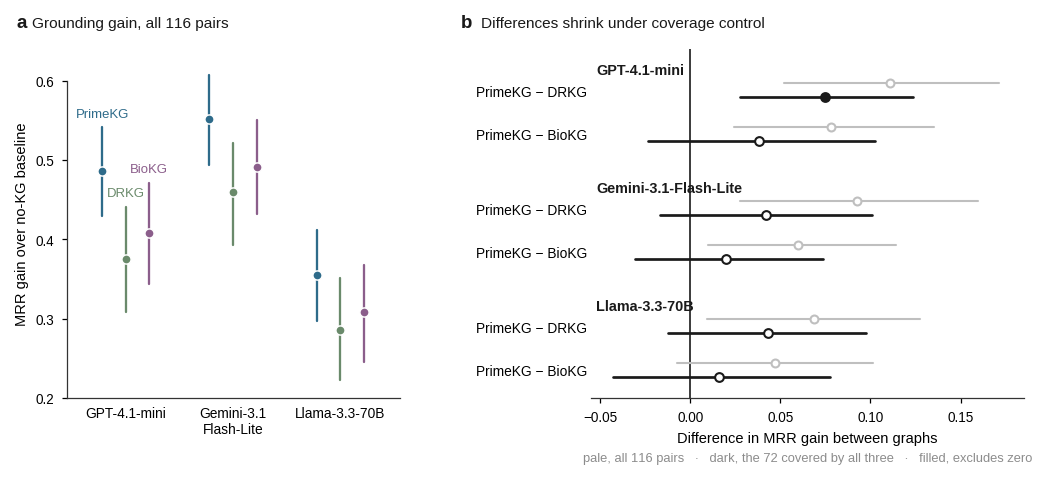

In [15]:
# Design notes: no gridlines competing with the data, one reference rule per
# panel, direct labelling instead of legends, and a tight-within / loose-
# between rhythm so the eye groups rows correctly. Panel b pairs each
# contrast on adjacent rows with a connector, so the attenuation under
# coverage control reads as a single movement rather than 18 loose intervals.

fig, (axa, axb) = plt.subplots(
    1, 2, figsize=(7.09, 3.30), gridspec_kw={"width_ratios": [1.0, 1.30]})
plt.subplots_adjust(left=0.085, right=0.985, bottom=0.155, top=0.86, wspace=0.50)

# ------------------------------------------------------------- a | lift
W = 0.22
for j, kg in enumerate(KG_ORDER):
    for i, m in enumerate(MODEL_ORDER):
        r = arms_main[(arms_main.model == m) & (arms_main.arm == kg)].iloc[0]
        x = i + (j - 1) * W
        axa.plot([x, x], [r.lift_lo, r.lift_hi], color=COL[kg], lw=1.1,
                 solid_capstyle="round", zorder=2)
        axa.plot([x], [r.lift], marker="o", ms=4.4, color=COL[kg],
                 mec="white", mew=0.7, zorder=3)
        if i == 0:                      # direct labels, no legend
            axa.annotate(kg, (x, r.lift_hi), xytext=(0, 5),
                         textcoords="offset points", ha="center",
                         fontsize=6.3, color=COL[kg])

axa.set_xticks(range(len(MODEL_ORDER)))
axa.set_xticklabels([m.replace("-Flash-Lite", "\nFlash-Lite")
                     for m in MODEL_ORDER], fontsize=6.6)
axa.set_ylabel("MRR gain over no-KG baseline", labelpad=3)
axa.set_ylim(0.20, 0.64)
axa.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6])
axa.set_xlim(-0.55, len(MODEL_ORDER) - 0.45)
axa.tick_params(axis="x", length=0, pad=4)
axa.grid(False)
for s_ in ("top", "right"):
    axa.spines[s_].set_visible(False)
axa.spines["left"].set_bounds(0.20, 0.60)
panel_letter(axa, "a", "Grounding gain, all 116 pairs", x=-0.15)

# --------------------------------------------------- b | paired contrasts
# Only the two PrimeKG contrasts are shown. BioKG - DRKG separates from zero
# in no model on either subset, so it adds six rows of overlapping intervals
# without carrying a claim; it lives in the supplementary table instead.
SHOW = ["PrimeKG - DRKG", "PrimeKG - BioKG"]
PAIR = 0.21

y, ticks, labels, heads = 0.0, [], [], []
for mi, m in enumerate(MODEL_ORDER):
    heads.append((y - 0.62, m))
    for con in SHOW:
        for frame, colr, off, lw, ms in ((con_main, FAINT, -PAIR, 1.0, 3.8),
                                         (con_cov, INK, PAIR, 1.3, 4.2)):
            r = frame[(frame.model == m) & (frame.contrast == con)]
            if r.empty:
                continue
            r = r.iloc[0]
            axb.plot([r.lo, r.hi], [y + off, y + off], color=colr, lw=lw,
                     solid_capstyle="round", zorder=2)
            axb.plot([r["diff"]], [y + off], marker="o", ms=ms, zorder=3,
                     mfc=colr if (r.separates and colr == INK) else "white",
                     mec=colr, mew=1.0)
        ticks.append(y)
        labels.append(con.replace(" - ", " \u2212 "))
        y += 1.30
    y += 0.95

axb.axvline(0, color=INK, lw=0.8, zorder=1)
axb.set_yticks(ticks)
axb.set_yticklabels(labels, fontsize=6.6)
axb.set_ylim(y - 0.95 - 0.45, -1.25)
axb.set_xlabel("Difference in MRR gain between graphs", labelpad=3)
axb.set_xlim(-0.055, 0.185)
axb.set_xticks([-0.05, 0, 0.05, 0.10, 0.15])
axb.tick_params(axis="y", length=0, pad=2)
axb.grid(False)
for s_ in ("top", "right", "left"):
    axb.spines[s_].set_visible(False)
for yh, m in heads:
    axb.text(-0.052, yh, m, fontsize=6.9, fontweight="bold", color=INK,
             va="center", ha="left")

axb.annotate(f"pale, all {N_MAIN} pairs   ·   dark, the {N_COV_PAIRS} covered "
             "by all three   ·   filled, excludes zero",
             xy=(0.5, -0.155), xycoords="axes fraction", ha="center",
             va="top", fontsize=6.2, color=MUTED)
panel_letter(axb, "b", "Differences shrink under coverage control", x=-0.30)

fig.savefig(FIGDIR / "Figure7.pdf", bbox_inches="tight", facecolor="white")
fig.savefig(FIGDIR / "Figure7.png", bbox_inches="tight", dpi=600,
            facecolor="white")
plt.show()

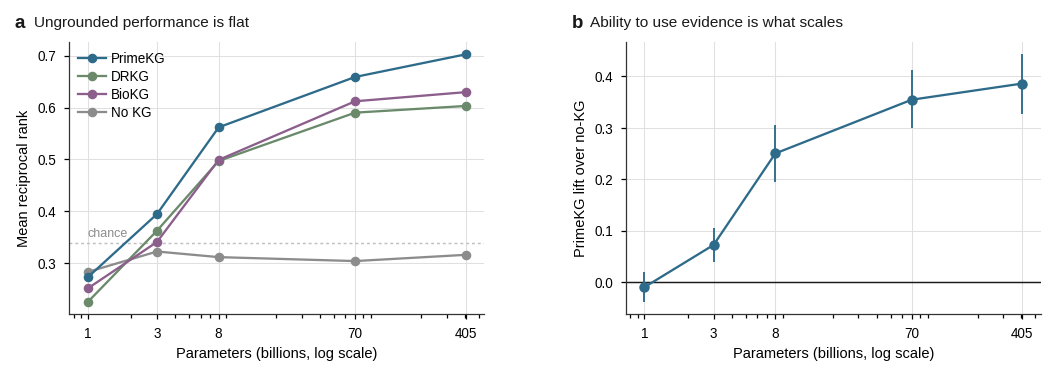

In [16]:
# ---------------------------------------- Supplementary | capacity series
figc, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.20, 2.75))
plt.subplots_adjust(left=0.085, right=0.985, bottom=0.20, top=0.86, wspace=0.34)

cx = cap.sort_values("params_B")
xs = sorted(cx.params_B.unique())

for kg in KG_ORDER + ["No KG"]:
    s = cx[cx.arm == kg].sort_values("params_B")
    colr = COL.get(kg, MUTED)
    ax1.plot(s.params_B, s.mrr, "-o", ms=3.6, lw=1.1, color=colr, label=kg,
             zorder=3 if kg != "No KG" else 2)
ax1.axhline(CHANCE_MRR, color=FAINT, ls=(0, (2, 2)), lw=0.7, zorder=1)
ax1.text(xs[0], CHANCE_MRR + 0.012, "chance", fontsize=6, color=MUTED)
ax1.set_xscale("log")
ax1.set_xticks(xs)
ax1.set_xticklabels([str(v) for v in xs])
ax1.set_xlabel("Parameters (billions, log scale)", labelpad=3)
ax1.set_ylabel("Mean reciprocal rank", labelpad=3)
ax1.grid(color=GRID_COLOR, lw=0.5)
ax1.set_axisbelow(True)
for s_ in ("top", "right"):
    ax1.spines[s_].set_visible(False)
ax1.legend(frameon=False, loc="upper left", handletextpad=0.4,
           labelspacing=0.3, borderaxespad=0.3)
panel_letter(ax1, "a", "Ungrounded performance is flat")

s = cx[cx.arm == "PrimeKG"].sort_values("params_B")
ax2.errorbar(s.params_B, s.lift,
             yerr=[s.lift - s.lift_lo, s.lift_hi - s.lift],
             fmt="-o", ms=4.0, lw=1.1, color=COL["PrimeKG"],
             ecolor=COL["PrimeKG"], elinewidth=0.9, capsize=0, zorder=3)
ax2.axhline(0, color=INK, lw=0.7, zorder=1)
ax2.set_xscale("log")
ax2.set_xticks(xs)
ax2.set_xticklabels([str(v) for v in xs])
ax2.set_xlabel("Parameters (billions, log scale)", labelpad=3)
ax2.set_ylabel("PrimeKG lift over no-KG", labelpad=3)
ax2.grid(color=GRID_COLOR, lw=0.5)
ax2.set_axisbelow(True)
for s_ in ("top", "right"):
    ax2.spines[s_].set_visible(False)
panel_letter(ax2, "b", "Ability to use evidence is what scales")

figc.savefig(FIGDIR / "FigureS_capacity.pdf", bbox_inches="tight",
             facecolor="white")
figc.savefig(FIGDIR / "FigureS_capacity.png", bbox_inches="tight", dpi=600,
             facecolor="white")
plt.show()

## 10 · Open questions this notebook cannot close

1. **Distractor coverage.** `coverage_annotation_v4.csv` scores only the
   positive of each pair. Distractors were sampled from Open Targets with no
   KG-presence requirement, so if the positive is often the only candidate
   carrying an evidence block, part of the measured lift is the model
   spotting the one candidate with any evidence at all. The same offline
   pass over `make_kg_block_fn` would settle it.
2. **`reconstruct_116_audit.csv` is stale.** It gives 105/85/73 and 67 in
   all three, against 111/90/78 and 72 here. `coverage_annotation_v4.csv`
   agrees with Figure 5b and is the one to trust; the audit file should be
   regenerated or removed.
3. **The 76-pair common-3 experiment is now redundant.** Coverage control
   happens within the 116-pair set, so the separate run survives only as a
   robustness check. Its missing Llama arm no longer blocks anything.